# 02 — Preprocessing Pipeline

This notebook demonstrates the preprocessing pipeline for preparing
GuitarDuets data for deep learning model input.

**Pipeline steps:**
1. Audio loading & resampling (44.1 kHz)
2. Stereo-to-mono conversion (for analysis; Demucs expects stereo)
3. MIDI → binary piano roll conversion
4. Segmentation into fixed-length chunks (4s default, matching the paper)
5. Batch processing & saving preprocessed segments

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from pathlib import Path
from tqdm.notebook import tqdm

from src.data_processing import (
    GuitarDuetsLoader, AudioPreprocessor, load_audio, load_audio_torch,
    load_midi, midi_to_piano_roll, midi_to_per_instrument_rolls,
    save_audio, Segment,
    DEMUCS_SR, SEGMENT_DURATION,
)

plt.rcParams["figure.dpi"] = 120

DATASET_ROOT = "../dataset"
OUTPUT_DIR = Path("../outputs/segments")

## 1. Audio Loading & Resampling

In [2]:
loader = GuitarDuetsLoader(DATASET_ROOT)
demo_track = loader.synth_tracks[0]
print(f"Track: {demo_track.track_id} — '{demo_track.piece_name}'")

# Load at native sample rate
audio_native = load_audio(demo_track.mix_path)
print(f"\nNative loading:")
print(f"  Sample rate:  {audio_native.sample_rate} Hz")
print(f"  Channels:     {audio_native.num_channels}")
print(f"  Duration:     {audio_native.duration:.2f} sec")
print(f"  Shape:        {audio_native.waveform.shape}")

# Load resampled to Demucs SR (should be no-op since dataset is already 44.1kHz)
audio_resampled = load_audio(demo_track.mix_path, sr=DEMUCS_SR)
print(f"\nResampled to {DEMUCS_SR} Hz:")
print(f"  Shape: {audio_resampled.waveform.shape}")

Track: synth_Track1 — 'Track1'

Native loading:
  Sample rate:  44100 Hz
  Channels:     2
  Duration:     120.00 sec
  Shape:        (2, 5292000)

Resampled to 44100 Hz:
  Shape: (2, 5292000)


## 2. Stereo vs. Mono

Stereo shape: (2, 5292000)
Mono shape:   (5292000,)


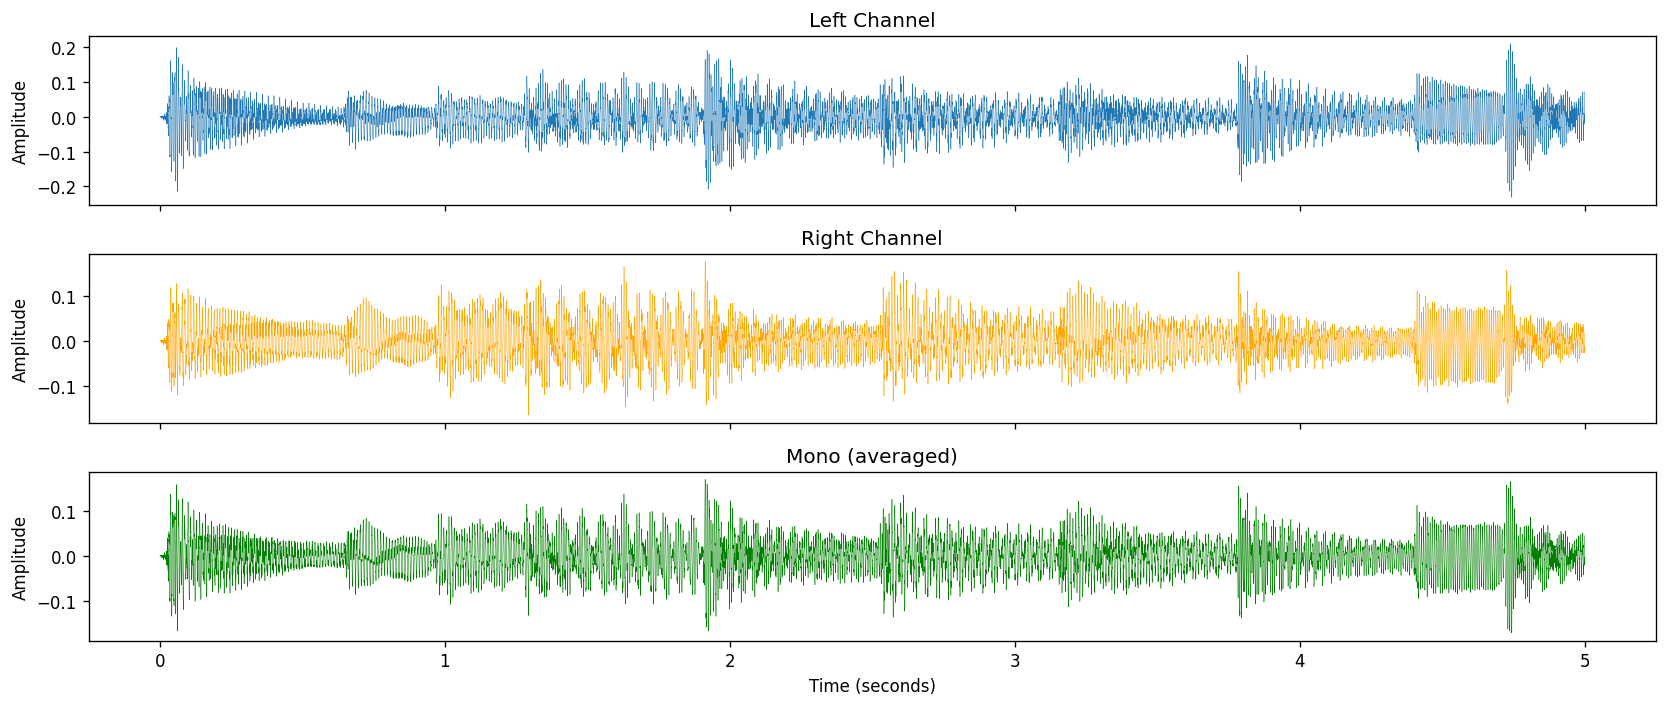

In [3]:
audio_stereo = load_audio(demo_track.mix_path, sr=DEMUCS_SR, mono=False)
audio_mono = load_audio(demo_track.mix_path, sr=DEMUCS_SR, mono=True)

print(f"Stereo shape: {audio_stereo.waveform.shape}")
print(f"Mono shape:   {audio_mono.waveform.shape}")

fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
vis_sec = 5
vis_n = int(vis_sec * DEMUCS_SR)
t = np.linspace(0, vis_sec, vis_n)

axes[0].plot(t, audio_stereo.waveform[0, :vis_n], linewidth=0.3)
axes[0].set_title("Left Channel")
axes[1].plot(t, audio_stereo.waveform[1, :vis_n], linewidth=0.3, color="orange")
axes[1].set_title("Right Channel")
axes[2].plot(t, audio_mono.waveform[:vis_n], linewidth=0.3, color="green")
axes[2].set_title("Mono (averaged)")
axes[2].set_xlabel("Time (seconds)")

for ax in axes:
    ax.set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

## 3. MIDI → Piano Roll

Full piano roll shape: (128, 11999)  (128 notes × 11999 frames at 100 fps)
Per-instrument rolls shape: (2, 128, 12000)  (2 instruments × 128 × 12000)


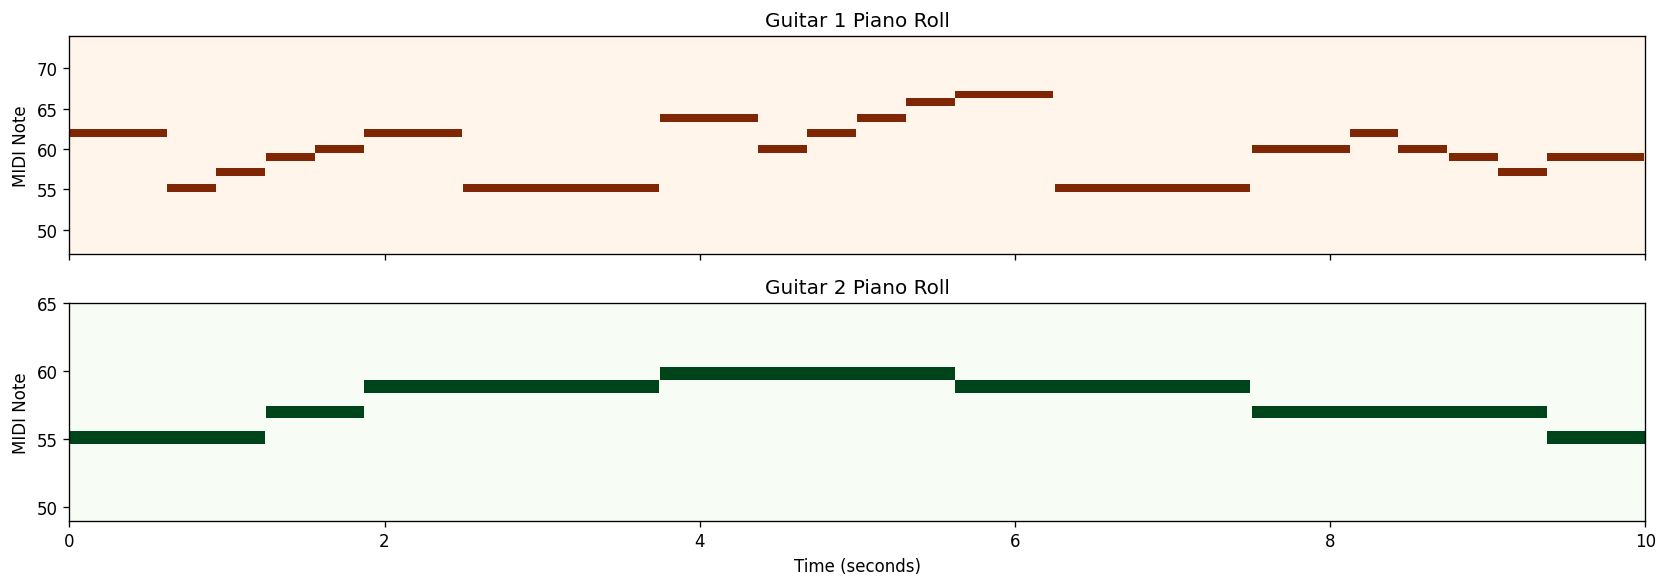

In [4]:
if demo_track.has_midi:
    midi = load_midi(demo_track.midi_path)

    # Full piano roll (combined)
    roll_full = midi_to_piano_roll(midi, fs=100)
    print(f"Full piano roll shape: {roll_full.shape}  (128 notes × {roll_full.shape[1]} frames at 100 fps)")

    # Per-instrument rolls
    rolls = midi_to_per_instrument_rolls(midi, fs=100, duration=audio_native.duration)
    print(f"Per-instrument rolls shape: {rolls.shape}  ({rolls.shape[0]} instruments × 128 × {rolls.shape[2]})")

    # Visualize first 10 seconds
    vis_frames = 10 * 100  # 10 sec × 100 fps
    fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
    for i in range(min(rolls.shape[0], 2)):
        active = np.where(rolls[i].sum(axis=1) > 0)[0]
        lo = max(0, active[0] - 3) if len(active) else 40
        hi = min(127, active[-1] + 3) if len(active) else 80
        axes[i].imshow(
            rolls[i, lo:hi+1, :vis_frames],
            aspect="auto", origin="lower",
            extent=[0, 10, lo, hi],
            cmap="Oranges" if i == 0 else "Greens",
            interpolation="nearest",
        )
        axes[i].set_title(f"Guitar {i+1} Piano Roll")
        axes[i].set_ylabel("MIDI Note")
    axes[-1].set_xlabel("Time (seconds)")
    plt.tight_layout()
    plt.show()
else:
    print("No MIDI available for this track — skipping piano roll demo.")

## 4. Audio Segmentation

The paper uses **4-second segments** as input to Demucs. We segment all
stems (mix, guitar1, guitar2) and MIDI consistently.

In [5]:
preprocessor = AudioPreprocessor(
    target_sr=DEMUCS_SR,
    segment_duration=SEGMENT_DURATION,  # 4 seconds
    hop_duration=SEGMENT_DURATION,       # non-overlapping
    mono=False,                          # keep stereo for Demucs
)

print(f"Segment duration: {preprocessor.segment_duration} sec")
print(f"Segment samples:  {preprocessor.segment_samples}")
print(f"Hop duration:     {preprocessor.hop_duration} sec")
print(f"Target SR:        {preprocessor.target_sr} Hz")

Segment duration: 4.0 sec
Segment samples:  176400
Hop duration:     4.0 sec
Target SR:        44100 Hz


In [6]:
segments = preprocessor.segment_track(demo_track)
print(f"Number of segments: {len(segments)}")
print(f"Expected: ceil({audio_native.duration:.1f} / {SEGMENT_DURATION}) = {int(np.ceil(audio_native.duration / SEGMENT_DURATION))}")

seg = segments[0]
print(f"\nFirst segment:")
print(f"  mix shape:     {seg.mix.shape}")
print(f"  guitar1 shape: {seg.guitar1.shape}")
print(f"  guitar2 shape: {seg.guitar2.shape}")
print(f"  time range:    [{seg.start_time:.1f}, {seg.end_time:.1f}] sec")
if seg.piano_roll is not None:
    print(f"  piano_roll:    {seg.piano_roll.shape}")

Number of segments: 30
Expected: ceil(120.0 / 4.0) = 30

First segment:
  mix shape:     (2, 176400)
  guitar1 shape: (2, 176400)
  guitar2 shape: (2, 176400)
  time range:    [0.0, 4.0] sec
  piano_roll:    (2, 128, 1)


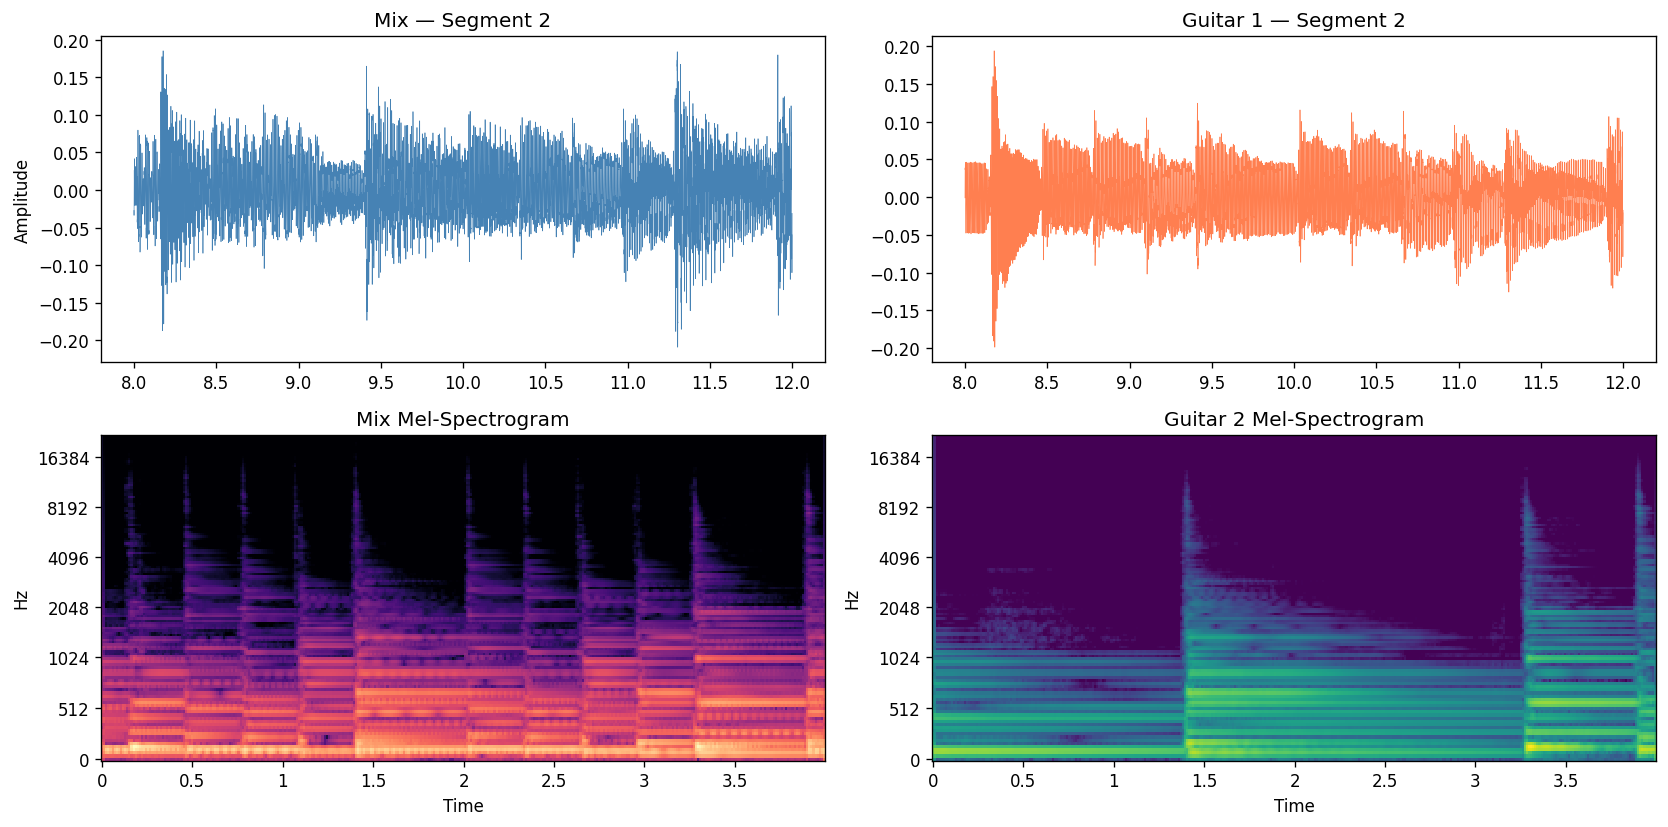

In [7]:
# Visualize a segment: waveforms + spectrogram
seg_idx = 2  # Pick the 3rd segment
seg = segments[min(seg_idx, len(segments) - 1)]

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

seg_t = np.linspace(seg.start_time, seg.end_time, seg.mix.shape[-1])

# Mix waveform (use channel 0)
mix_ch = seg.mix[0] if seg.mix.ndim == 2 else seg.mix
g1_ch = seg.guitar1[0] if seg.guitar1.ndim == 2 else seg.guitar1
g2_ch = seg.guitar2[0] if seg.guitar2.ndim == 2 else seg.guitar2

axes[0, 0].plot(seg_t, mix_ch, linewidth=0.4, color="steelblue")
axes[0, 0].set_title(f"Mix — Segment {seg_idx}")
axes[0, 0].set_ylabel("Amplitude")

axes[0, 1].plot(seg_t, g1_ch, linewidth=0.4, color="coral")
axes[0, 1].set_title(f"Guitar 1 — Segment {seg_idx}")

# Mel-spectrograms
mel_seg_mix = librosa.feature.melspectrogram(y=mix_ch, sr=DEMUCS_SR, n_mels=128)
mel_seg_g2 = librosa.feature.melspectrogram(y=g2_ch, sr=DEMUCS_SR, n_mels=128)

librosa.display.specshow(
    librosa.power_to_db(mel_seg_mix, ref=np.max),
    sr=DEMUCS_SR, x_axis="time", y_axis="mel", ax=axes[1, 0], cmap="magma",
)
axes[1, 0].set_title("Mix Mel-Spectrogram")

librosa.display.specshow(
    librosa.power_to_db(mel_seg_g2, ref=np.max),
    sr=DEMUCS_SR, x_axis="time", y_axis="mel", ax=axes[1, 1], cmap="viridis",
)
axes[1, 1].set_title("Guitar 2 Mel-Spectrogram")

plt.tight_layout()
plt.show()

## 5. Batch Processing

Process all tracks and save segments to disk. We save as `.npz` files
for fast loading during training.

In [8]:
def save_segments(segments: list[Segment], output_dir: Path) -> int:
    """Save a list of segments to disk as individual .npz files."""
    output_dir.mkdir(parents=True, exist_ok=True)
    count = 0
    for i, seg in enumerate(segments):
        fname = output_dir / f"{seg.track_id}_seg{i:04d}.npz"
        data = {
            "mix": seg.mix,
            "guitar1": seg.guitar1,
            "guitar2": seg.guitar2,
            "start_time": seg.start_time,
            "end_time": seg.end_time,
            "track_id": seg.track_id,
        }
        if seg.piano_roll is not None:
            data["piano_roll"] = seg.piano_roll
        np.savez_compressed(str(fname), **data)
        count += 1
    return count

In [9]:
# Process all tracks (this may take a few minutes)
preprocessor_stereo = AudioPreprocessor(
    target_sr=DEMUCS_SR,
    segment_duration=SEGMENT_DURATION,
    mono=False,
)

total_segments = 0
errors = []

all_tracks = loader.get_all_tracks()
for track in tqdm(all_tracks, desc="Processing tracks"):
    try:
        segs = preprocessor_stereo.segment_track(track)
        subset_dir = OUTPUT_DIR / track.subset
        n_saved = save_segments(segs, subset_dir)
        total_segments += n_saved
    except Exception as e:
        errors.append((track.track_id, str(e)))
        print(f"Error on {track.track_id}: {e}")

print(f"\nDone! Total segments saved: {total_segments}")
if errors:
    print(f"Errors encountered: {len(errors)}")
    for tid, msg in errors:
        print(f"  {tid}: {msg}")

Processing tracks:   0%|          | 0/70 [00:00<?, ?it/s]


Done! Total segments saved: 2574


In [10]:
# Verify: load a saved segment back
sample_files = sorted(OUTPUT_DIR.glob("**/*.npz"))
if sample_files:
    data = np.load(str(sample_files[0]), allow_pickle=True)
    print(f"Loaded: {sample_files[0].name}")
    print(f"Keys: {list(data.keys())}")
    for key in data.keys():
        val = data[key]
        if hasattr(val, 'shape'):
            print(f"  {key}: shape={val.shape}, dtype={val.dtype}")
        else:
            print(f"  {key}: {val}")
else:
    print("No segments found — run the batch processing cell above first.")

Loaded: real_Summer Garden 1 3rd_seg0000.npz
Keys: ['mix', 'guitar1', 'guitar2', 'start_time', 'end_time', 'track_id']
  mix: shape=(2, 176400), dtype=float64
  guitar1: shape=(2, 176400), dtype=float64
  guitar2: shape=(2, 176400), dtype=float64
  start_time: shape=(), dtype=float64
  end_time: shape=(), dtype=float64
  track_id: shape=(), dtype=<U24


## Summary

The preprocessing pipeline produces:
- **Stereo 4-second segments** at 44.1 kHz for Demucs input
- Aligned **mix**, **guitar1**, **guitar2** waveforms per segment
- **Piano roll annotations** (for synth tracks) aligned to each segment
- All saved as `.npz` for efficient loading during training

Each segment contains `4 × 44100 = 176,400` samples per channel.